Notebook 02 — Spatial Analysis and Contextual Data
Purpose: Clip ACS-enriched tracts to Foggy Bottom and integrate OSM data

In [2]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import matplotlib.pyplot as plt

In [3]:
tracts_acs = gpd.read_parquet("data/processed/acs_merged.parquet")
tracts_acs.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,B15003_025E,B25077_001E,B23025_002E,B23025_004E,B23025_005E,pct_white,pct_black,pct_asian,pct_bachelors,unemployment_rate
0,11,001,005302,11001005302,1400000US11001005302,53.02,Census Tract 53.02,G5020,S,117635,...,108,497300,1975,1959,0,0.766392,0.033765,0.096977,0.526190,0.000000
1,11,001,004402,11001004402,1400000US11001004402,44.02,Census Tract 44.02,G5020,S,274746,...,129,1022400,1810,1690,104,0.633640,0.139033,0.060328,0.400265,0.057459
2,11,001,010602,11001010602,1400000US11001010602,106.02,Census Tract 106.02,G5020,S,542512,...,417,992100,5294,5112,169,0.541478,0.304168,0.058605,0.359153,0.031923
3,11,001,000804,11001000804,1400000US11001000804,8.04,Census Tract 8.04,G5020,S,2566768,...,174,1891400,1529,1454,52,0.841733,0.022933,0.030294,0.440000,0.034009
4,11,001,003902,11001003902,1400000US11001003902,39.02,Census Tract 39.02,G5020,S,266513,...,104,578400,1324,1315,0,0.560316,0.051297,0.173055,0.435368,0.000000


In [4]:
foggy = ox.geocode_to_gdf("Foggy Bottom, Washington, DC")

foggy = foggy.to_crs(tracts_acs.crs)

foggy

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-77.05847 38.90121, -77.05845 38.901...",-77.058467,38.896056,-77.043539,38.902547,323458992,relation,4639510,38.899114,-77.054728,place,neighbourhood,24,0.421658,suburb,Foggy Bottom,"Foggy Bottom, Ward 2, Washington, District of ..."


In [6]:
#Clipping ACS tracts to Foggy Bottom
foggy_tracts = gpd.overlay(tracts_acs, foggy, how="intersection")
foggy_tracts = foggy_tracts[tracts_acs.columns]

foggy_tracts


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,B15003_025E,B25077_001E,B23025_002E,B23025_004E,B23025_005E,pct_white,pct_black,pct_asian,pct_bachelors,unemployment_rate
0,11,001,000102,11001000102,1400000US11001000102,1.02,Census Tract 1.02,G5020,S,1706484,...,298,1238100,1960,1926,34,0.847513,0.004908,0.027160,0.494597,0.017347
1,11,001,005601,11001005601,1400000US11001005601,56.01,Census Tract 56.01,G5020,S,185309,...,131,481900,1861,1690,104,0.654306,0.110845,0.129585,0.453198,0.055884
2,11,001,005602,11001005602,1400000US11001005602,56.02,Census Tract 56.02,G5020,S,273491,...,437,943200,1923,1870,53,0.641795,0.065940,0.126921,0.351024,0.027561
3,11,001,980000,11001980000,1400000US11001980000,9800,Census Tract 9800,G5020,S,6514228,...,0,-666666666,17,17,0,1.000000,0.000000,0.000000,1.000000,0.000000
4,11,001,010800,11001010800,1400000US11001010800,108,Census Tract 108,G5020,S,661580,...,72,255700,2071,1795,276,0.584654,0.099133,0.195730,0.341270,0.133269


In [13]:
#Pulling OSM Roads
from osmnx import features

roads = ox.features_from_polygon(
    foggy.geometry.iloc[0],
    tags={"highway": True}
)


In [ ]:
#Buildings
buildings = ox.features_from_polygon(
    foggy.geometry.iloc[0],
    tags={"building": True}
)

In [15]:
#Pulling amenities
amenities = ox.features_from_polygon(
    foggy.geometry.iloc[0],
    tags={"amenity": True}
)


In [ ]:
# Keeping only LineString/MultiLineString for roads
roads = roads[roads.geometry.type.isin(["LineString", "MultiLineString"])]

# Keeping only Polygon/MultiPolygon for buildings
buildings = buildings[buildings.geometry.type.isin(["Polygon", "MultiPolygon"])]


Creating first contextual map

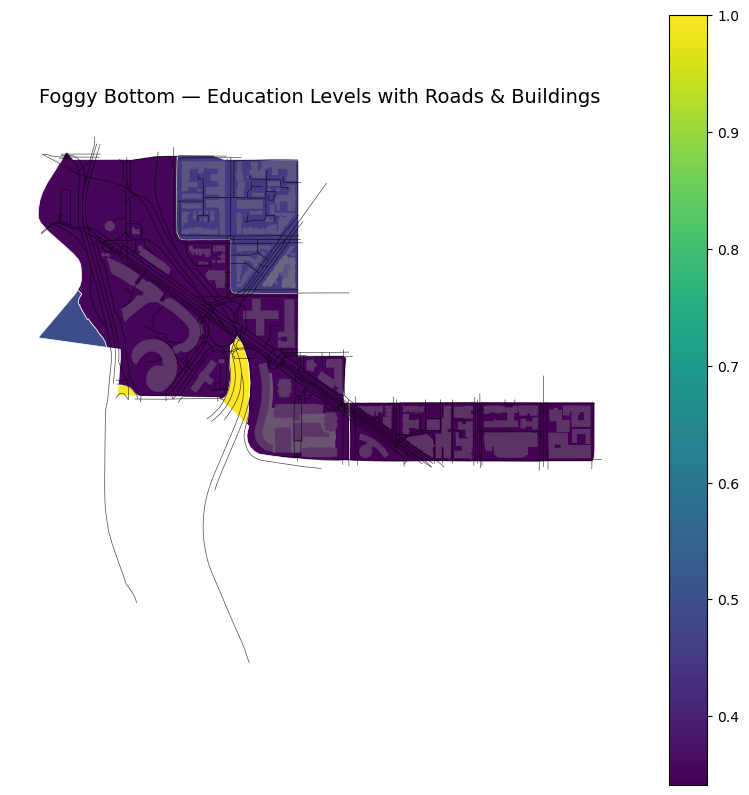

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

# ACS tracts (Foggy Bottom)
foggy_tracts.plot(
    ax=ax,
    column="pct_bachelors",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.5
)

# Roads
roads.plot(ax=ax, color="black", linewidth=0.5, alpha=0.7)

# Buildings
buildings.plot(ax=ax, color="grey", alpha=0.4)

plt.title("Foggy Bottom — Education Levels with Roads & Buildings", fontsize=14)
plt.axis("off")
plt.show()


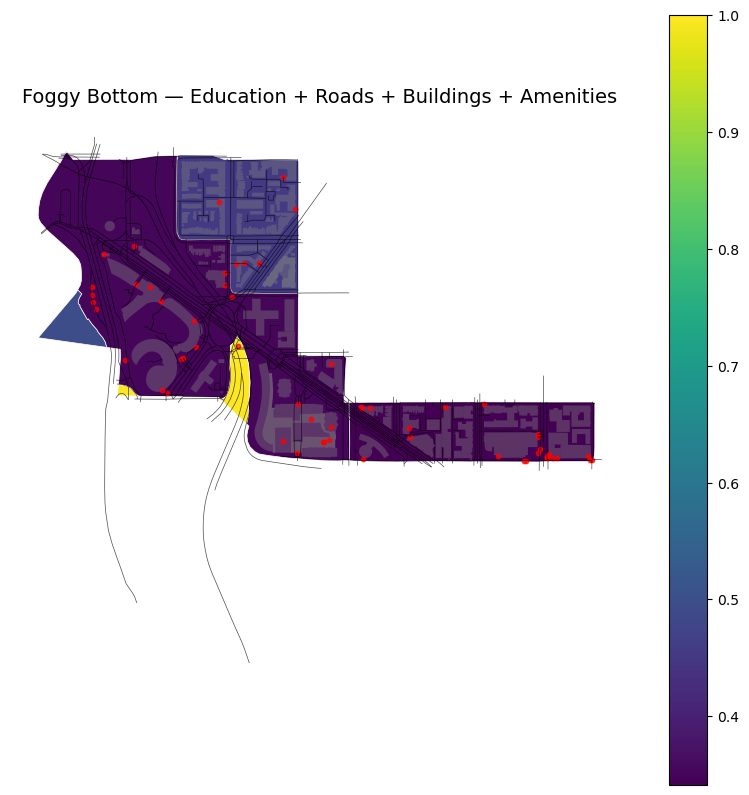

In [18]:
#Adding Amenities
amenities_points = amenities[amenities.geometry.type == "Point"]

fig, ax = plt.subplots(figsize=(10, 10))

foggy_tracts.plot(
    ax=ax,
    column="pct_bachelors",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.5
)

roads.plot(ax=ax, color="black", linewidth=0.5, alpha=0.7)
buildings.plot(ax=ax, color="grey", alpha=0.4)

amenities_points.plot(ax=ax, color="red", markersize=10, alpha=0.7)

plt.title("Foggy Bottom — Education + Roads + Buildings + Amenities", fontsize=14)
plt.axis("off")
plt.show()


In [19]:
roads.to_file("data/processed/foggy_roads.geojson", driver="GeoJSON")
buildings.to_file("data/processed/foggy_buildings.geojson", driver="GeoJSON")
amenities.to_file("data/processed/foggy_amenities.geojson", driver="GeoJSON")


In [20]:
foggy_tracts.to_file("data/processed/foggy_tracts.geojson", driver="GeoJSON")
